In [1]:
import pandas as pd

train_df = pd.read_csv('~/data/training_data_small_with_calender_features.csv')
test_df = pd.read_csv('~/data/test_data_small_with_calender_features.csv')


train_df['ds'] = pd.to_datetime(train_df['ds'])
test_df['ds'] = pd.to_datetime(test_df['ds'])

# Check date ranges
print("First date in train_df:", train_df['ds'].min())
print("Last date in train_df:", train_df['ds'].max())
print("First date in test_df:", test_df['ds'].min())
print("Last date in test_df:", test_df['ds'].max())

# Define the exogenous variable lists
stat_exog_list = []  # Add any static variables if applicable
hist_exog_list = ['month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos',
                  'hour_sin', 'hour_cos', 'is_holiday', 'is_weekend']

futr_exog_list = hist_exog_list 

First date in train_df: 2022-12-31 23:00:00
Last date in train_df: 2024-01-01 22:00:00
First date in test_df: 2023-12-31 23:00:00
Last date in test_df: 2024-04-01 22:00:00


In [2]:
train_df.head()

,ds,y,unique_id,day_of_week,month,hour,is_weekend,is_holiday,month_sin,month_cos,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
0,2022-12-31 23:00:00,-5.17,electricity_prices,5,12,23,1,0,-2.449294e-16,1.000000,-0.974928,-0.222521,-0.258819,0.965926
1,2023-01-01 00:00:00,-1.07,electricity_prices,6,1,0,1,1,5.000000e-01,0.866025,-0.781831,0.623490,0.000000,1.000000
2,2023-01-01 01:00:00,-1.47,electricity_prices,6,1,1,1,1,5.000000e-01,0.866025,-0.781831,0.623490,0.258819,0.965926
3,2023-01-01 02:00:00,-5.08,electricity_prices,6,1,2,1,1,5.000000e-01,0.866025,-0.781831,0.623490,0.500000,0.866025
4,2023-01-01 03:00:00,-4.49,electricity_prices,6,1,3,1,1,5.000000e-01,0.866025,-0.781831,0.623490,0.707107,0.707107


In [3]:
test_df.head()

,ds,y,unique_id,day_of_week,month,hour,is_weekend,is_holiday,month_sin,month_cos,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
0,2023-12-31 23:00:00,0.10,electricity_prices,6,12,23,1,0,-2.449294e-16,1.000000,-0.781831,0.62349,-0.258819,0.965926
1,2024-01-01 00:00:00,0.01,electricity_prices,0,1,0,0,1,5.000000e-01,0.866025,0.000000,1.00000,0.000000,1.000000
2,2024-01-01 01:00:00,0.00,electricity_prices,0,1,1,0,1,5.000000e-01,0.866025,0.000000,1.00000,0.258819,0.965926
3,2024-01-01 02:00:00,-0.01,electricity_prices,0,1,2,0,1,5.000000e-01,0.866025,0.000000,1.00000,0.500000,0.866025
4,2024-01-01 03:00:00,-0.03,electricity_prices,0,1,3,0,1,5.000000e-01,0.866025,0.000000,1.00000,0.707107,0.707107


Train the Model

In [4]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM

horizon = 24
historical = 24

model_name = 'LSTM'

# Set up the model with horizon = 24 (for day-ahead hourly forecasts)
models = [
    LSTM(
        h=horizon,  # Forecast horizon set to 24 to predict the next day's 24 hours
        input_size=historical, # Input size regarding how much info the model gets to forecast the next day
        max_steps=2000,
        stat_exog_list=stat_exog_list,
        hist_exog_list=hist_exog_list,
        futr_exog_list=futr_exog_list,
        scaler_type='standard',
        encoder_n_layers=2,
        encoder_hidden_size=100,
        decoder_hidden_size=512,
    ),
]

# Train the model on the entire training data just once
nf = NeuralForecast(models=models, freq='h')
nf.fit(df=train_df)

[rank: 0] Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/4
Initializing distributed: GLOBAL_RANK: 3, MEMBER: 4/4
Initializing distributed: GLOBAL_RANK: 2, MEMBER: 3/4
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/4
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 4 processes
----------------------------------------------------------------------------------------------------

2025-01-07 10:18:46.453162: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-07 10:18:46.468268: E external/local_xla/xla/strea

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=2000` reached.
/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Test the model

In [5]:
# Define the date range based on the test dataset
daterange = pd.date_range(
    start=test_df['ds'].min(),
    end=test_df['ds'].max() - pd.Timedelta(hours=historical),
    freq='24H'
)

historicalTime = pd.Timedelta(hours=historical)

# Generate predictions for each 7-day window
predictions = [
    nf.predict(
        df = test_df[(test_df['ds'] >= d) & (test_df['ds'] < d + historicalTime)],
        futr_df=test_df[(test_df['ds'] >= (d + historicalTime))]
    )
    for d in daterange
]

# Flatten the predictions into a DataFrame
forecast_df = pd.concat(predictions, ignore_index=True)

/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:940: UserWarning: Dropped 2,160 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
2025-01-07 10:19:18.222620: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-07 10:19:18.237132: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736241558.253671  113461 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already b

Predicting: |          | 0/? [00:00<?, ?it/s]

/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:214: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(
/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:940: UserWarning: Dropped 2,136 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting: |          | 0/? [00:00<?, ?it/s]

/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:214: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(
/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:940: UserWarning: Dropped 2,112 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


...

/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:214: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(
/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:940: UserWarning: Dropped 24 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting: |          | 0/? [00:00<?, ?it/s]

/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:214: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting: |          | 0/? [00:00<?, ?it/s]

/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/neuralforecast/core.py:214: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


In [6]:
forecast_df.head()

,ds,LSTM
0,2024-01-01 23:00:00,15.814648
1,2024-01-02 00:00:00,19.397448
2,2024-01-02 01:00:00,18.555727
3,2024-01-02 02:00:00,17.761362
4,2024-01-02 03:00:00,14.323960


In [7]:
# Ensure the results align with the test dataset
forecast_df = forecast_df[['ds', model_name ]].merge(test_df[['ds', 'y']], on='ds', how='inner')

In [8]:
forecast_df.head()

,ds,LSTM,y
0,2024-01-01 23:00:00,15.814648,30.59
1,2024-01-02 00:00:00,19.397448,20.07
2,2024-01-02 01:00:00,18.555727,31.03
3,2024-01-02 02:00:00,17.761362,18.39
4,2024-01-02 03:00:00,14.323960,11.08


In [9]:
forecast_df.rename(columns={'y': 'y_actual', model_name: 'y_pred'}, inplace=True)

Plots

In [10]:
forecast_df.head()

,ds,y_pred,y_actual
0,2024-01-01 23:00:00,15.814648,30.59
1,2024-01-02 00:00:00,19.397448,20.07
2,2024-01-02 01:00:00,18.555727,31.03
3,2024-01-02 02:00:00,17.761362,18.39
4,2024-01-02 03:00:00,14.323960,11.08


In [11]:
forecast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2184 entries, 0 to 2183
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   ds        2184 non-null   datetime64[ns]
 1   y_pred    2184 non-null   float32       
 2   y_actual  2184 non-null   float64       
dtypes: datetime64[ns](1), float32(1), float64(1)
memory usage: 42.8 KB


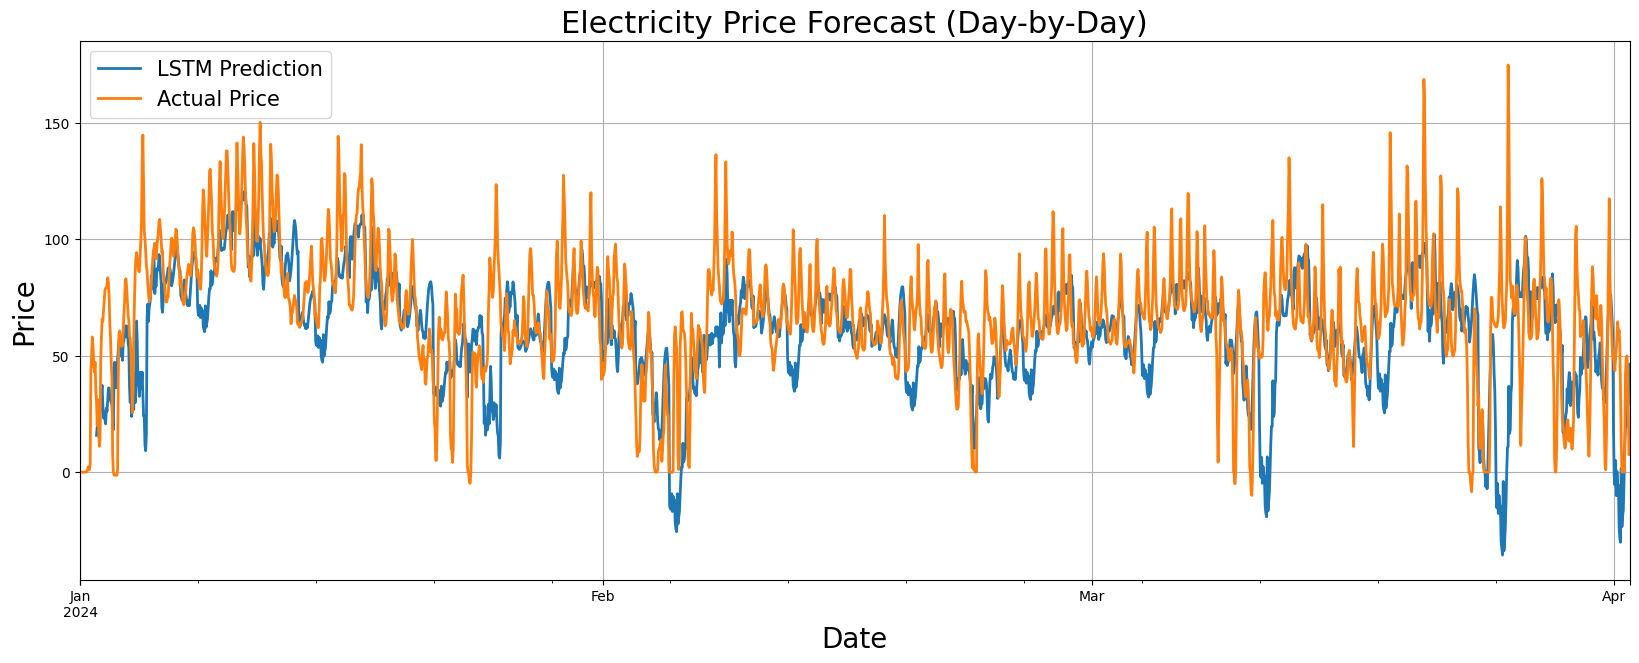

In [12]:
import matplotlib.pyplot as plt

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(20, 7))

# Plot predictions for model
forecast_df.set_index('ds')['y_pred'].plot(ax=ax, linewidth=2, label= f'{model_name} Prediction')

# Optional: Plot actual test values for comparison
test_df.set_index('ds')['y'].plot(ax=ax, linewidth=2, label='Actual Price')

# Formatting the plot
ax.set_title('Electricity Price Forecast (Day-by-Day)', fontsize=22)
ax.set_ylabel('Price', fontsize=20)
ax.set_xlabel('Date', fontsize=20)
ax.legend(prop={'size': 15})
ax.grid()
plt.show()

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate error metrics
mae = mean_absolute_error(forecast_df['y_actual'], forecast_df['y_pred'])
mse = mean_squared_error(forecast_df['y_actual'], forecast_df['y_pred'])
rmse = np.sqrt(mse)

# Print the results
print("Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Model Performance:
Mean Absolute Error (MAE): 17.98
Mean Squared Error (MSE): 664.76
Root Mean Squared Error (RMSE): 25.78


In [14]:
# Merge forecasted values with actual test data, selecting only the relevant columns
comparison_df = forecast_df[['ds', 'y_pred']].merge(test_df[['ds', 'y']], on='ds', how='inner')
comparison_df.rename(columns={'y': 'y_actual', 'y_pred': 'y_pred'}, inplace=True)

# Add a column for the day of the week (0=Monday, 1=Tuesday, ..., 6=Sunday)
comparison_df['day_of_week'] = comparison_df['ds'].dt.dayofweek

# Calculate and display MAE, MSE, and RMSE for each day of the week
metrics_by_day = {}

for day in range(7):
    # Filter data for each day of the week
    day_data = comparison_df[comparison_df['day_of_week'] == day]

    # Calculate the metrics for this day
    mae = mean_absolute_error(day_data['y_actual'], day_data['y_pred'])
    mse = mean_squared_error(day_data['y_actual'], day_data['y_pred'])
    rmse = np.sqrt(mse)

    # Store the metrics for each day
    metrics_by_day[day] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    }

# Optionally, you can store these results in a DataFrame for easy viewing or further analysis
metrics_df = pd.DataFrame(metrics_by_day).T
print("\nMetrics by Day of the Week:")
print(metrics_df)


Metrics by Day of the Week:
         MAE          MSE       RMSE
0  37.834228  2136.129899  46.218285
1  13.382305   348.655817  18.672328
2  15.663695   406.794867  20.169156
3  21.516318   901.221684  30.020354
4  13.256478   309.835832  17.602154
5  12.876312   348.359450  18.664390
6  11.300336   202.291742  14.222930


In [15]:
overall_mean = test_df['y'].mean()

# Print the overall mean
print(f"Overall Mean Price: {overall_mean}")

Overall Mean Price: 67.30137681159421


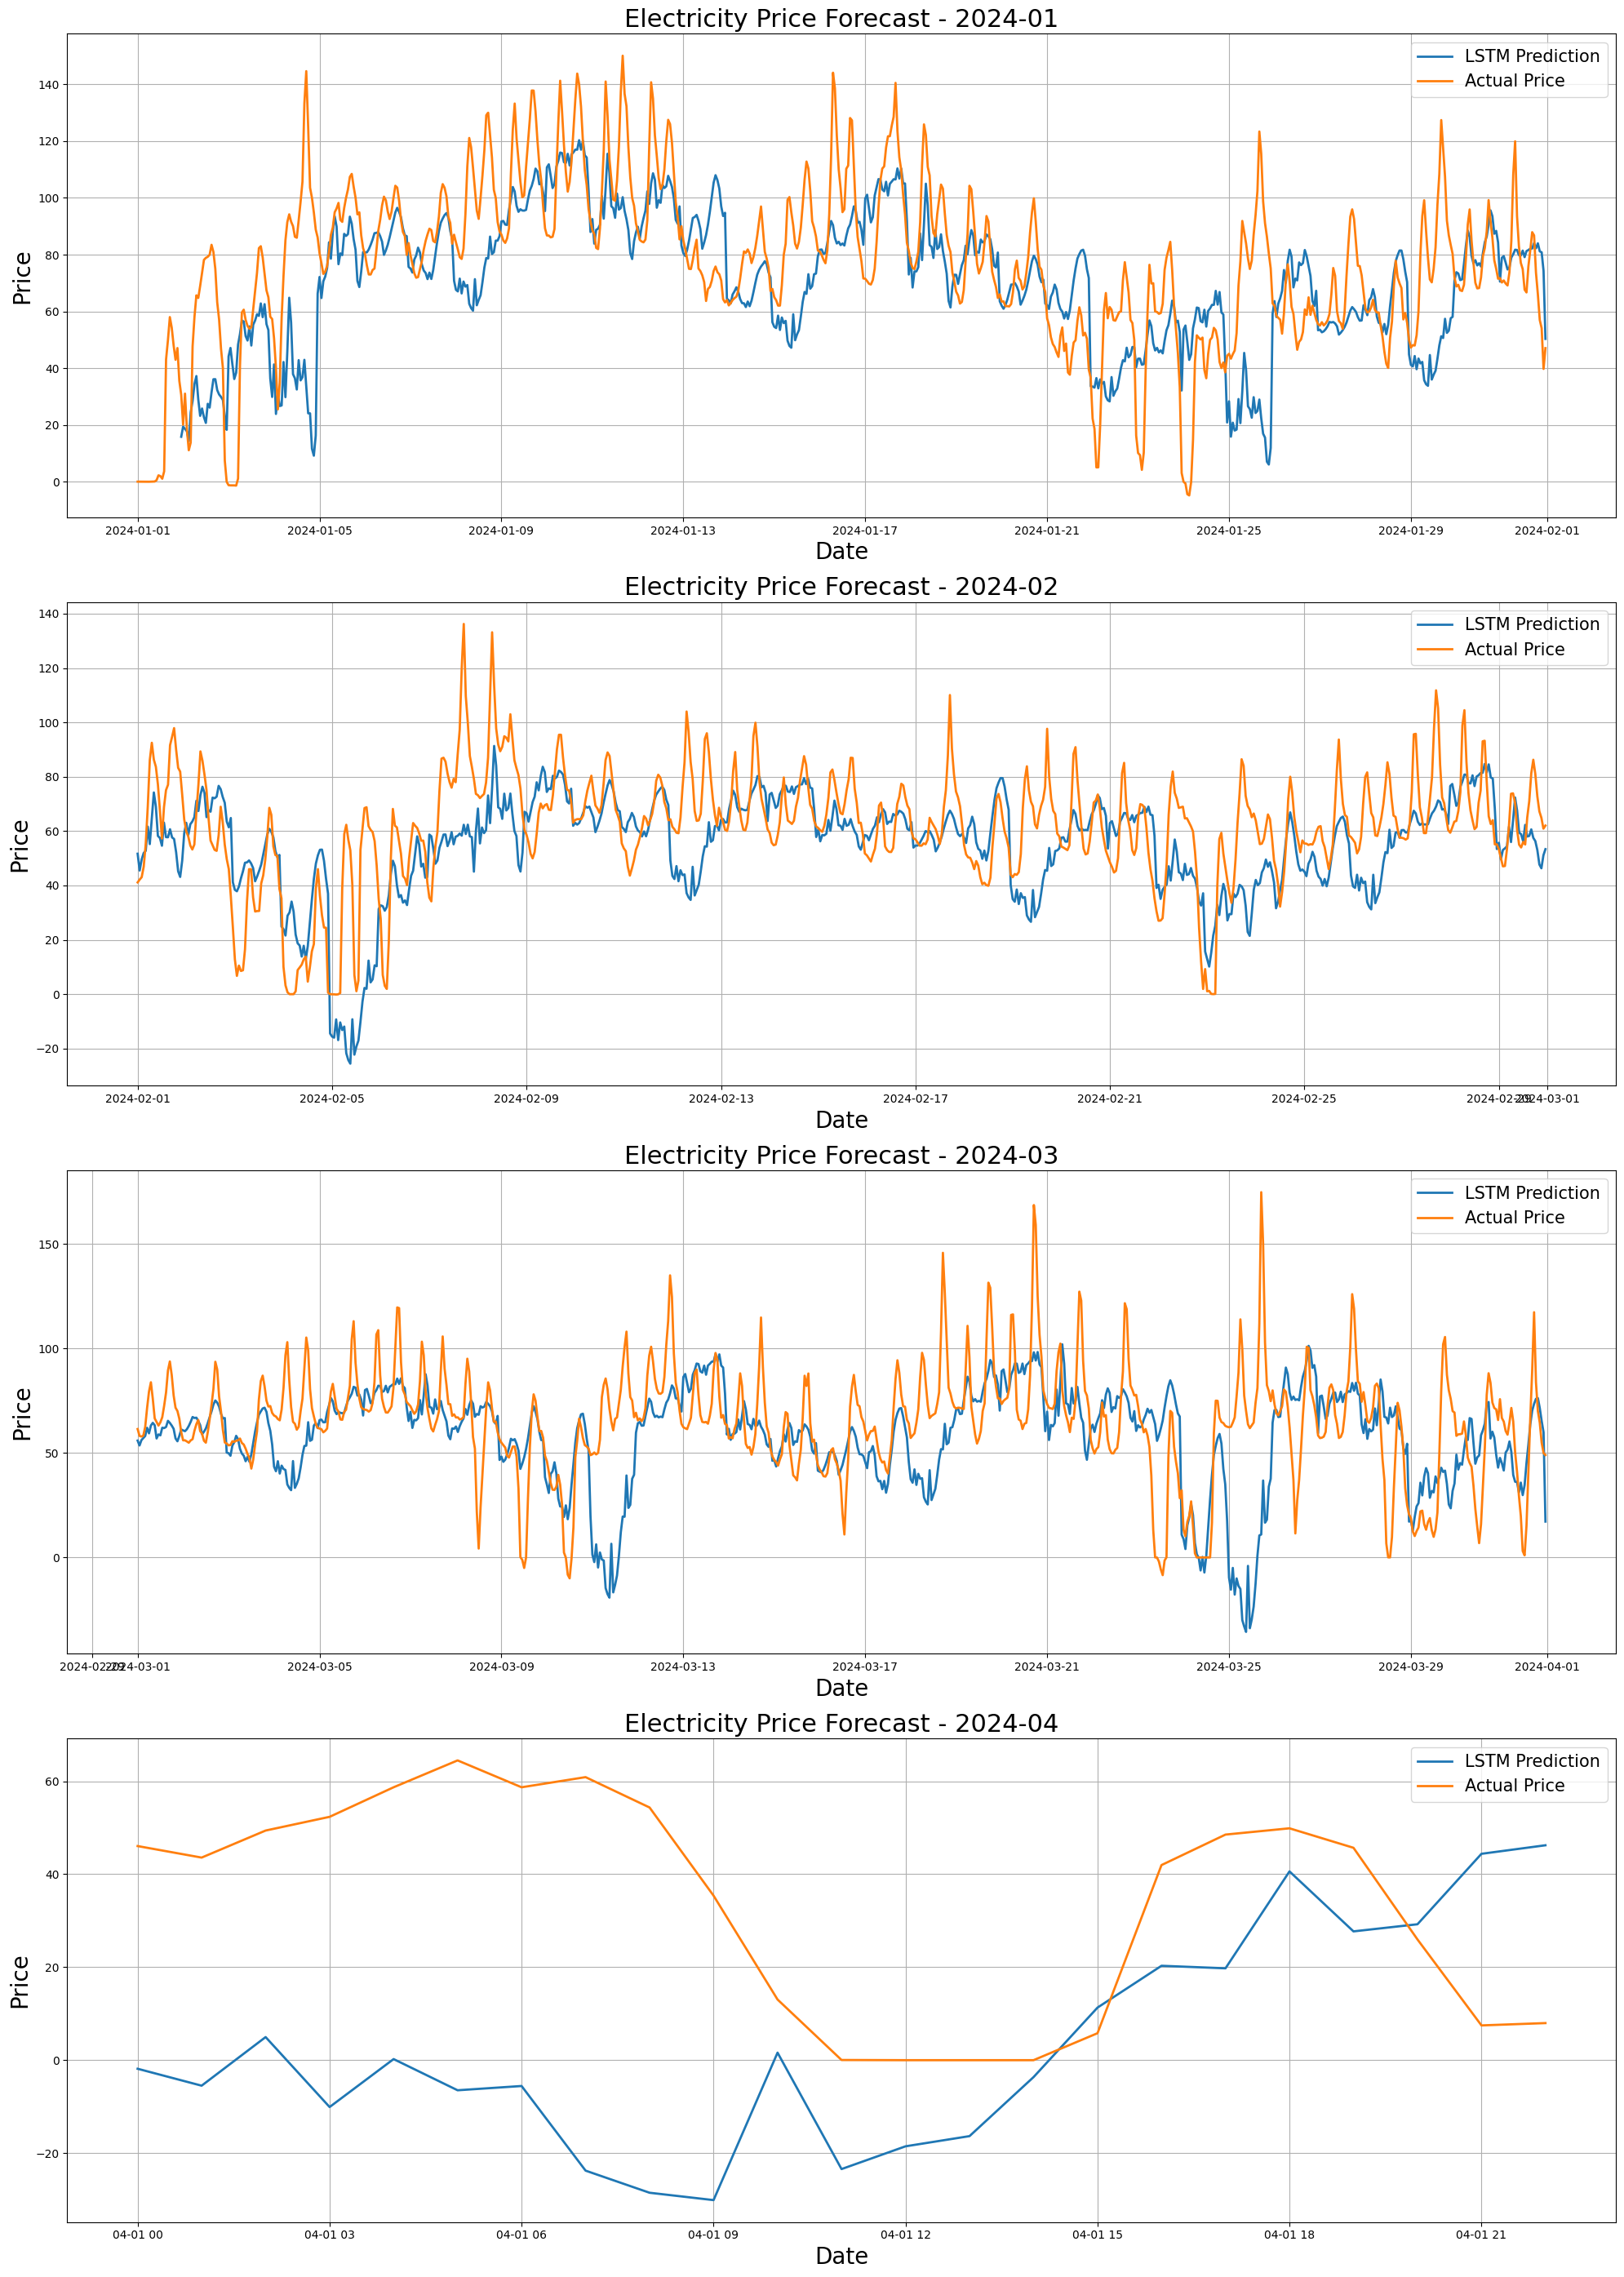

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'ds' is in datetime format
forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])
test_df['ds'] = pd.to_datetime(test_df['ds'])

# Create a new figure with multiple subplots, one for each month
unique_months = forecast_df['ds'].dt.to_period('M').unique()

# Set up the figure and axes for plotting
fig, axes = plt.subplots(len(unique_months), 1, figsize=(20, 7 * len(unique_months)))

if len(unique_months) == 1:
    axes = [axes]  # Ensure axes is iterable even if there's only one subplot

for i, month in enumerate(unique_months):
    # Create the data subset for the current month
    month_str = str(month)
    forecast_month = forecast_df[forecast_df['ds'].dt.to_period('M') == month]
    test_month = test_df[test_df['ds'].dt.to_period('M') == month]

    # Plot predictions for the current month
    axes[i].plot(forecast_month['ds'], forecast_month['y_pred'], linewidth=2, label=f'{model_name} Prediction')

    # Plot actual test values for comparison in the current month
    axes[i].plot(test_month['ds'], test_month['y'], linewidth=2, label='Actual Price')

    # Formatting the plot for the current month
    axes[i].set_title(f'Electricity Price Forecast - {month_str}', fontsize=22)
    axes[i].set_ylabel('Price', fontsize=20)
    axes[i].set_xlabel('Date', fontsize=20)
    axes[i].legend(prop={'size': 15})
    axes[i].grid()

# Show the plot
plt.tight_layout()
plt.show()

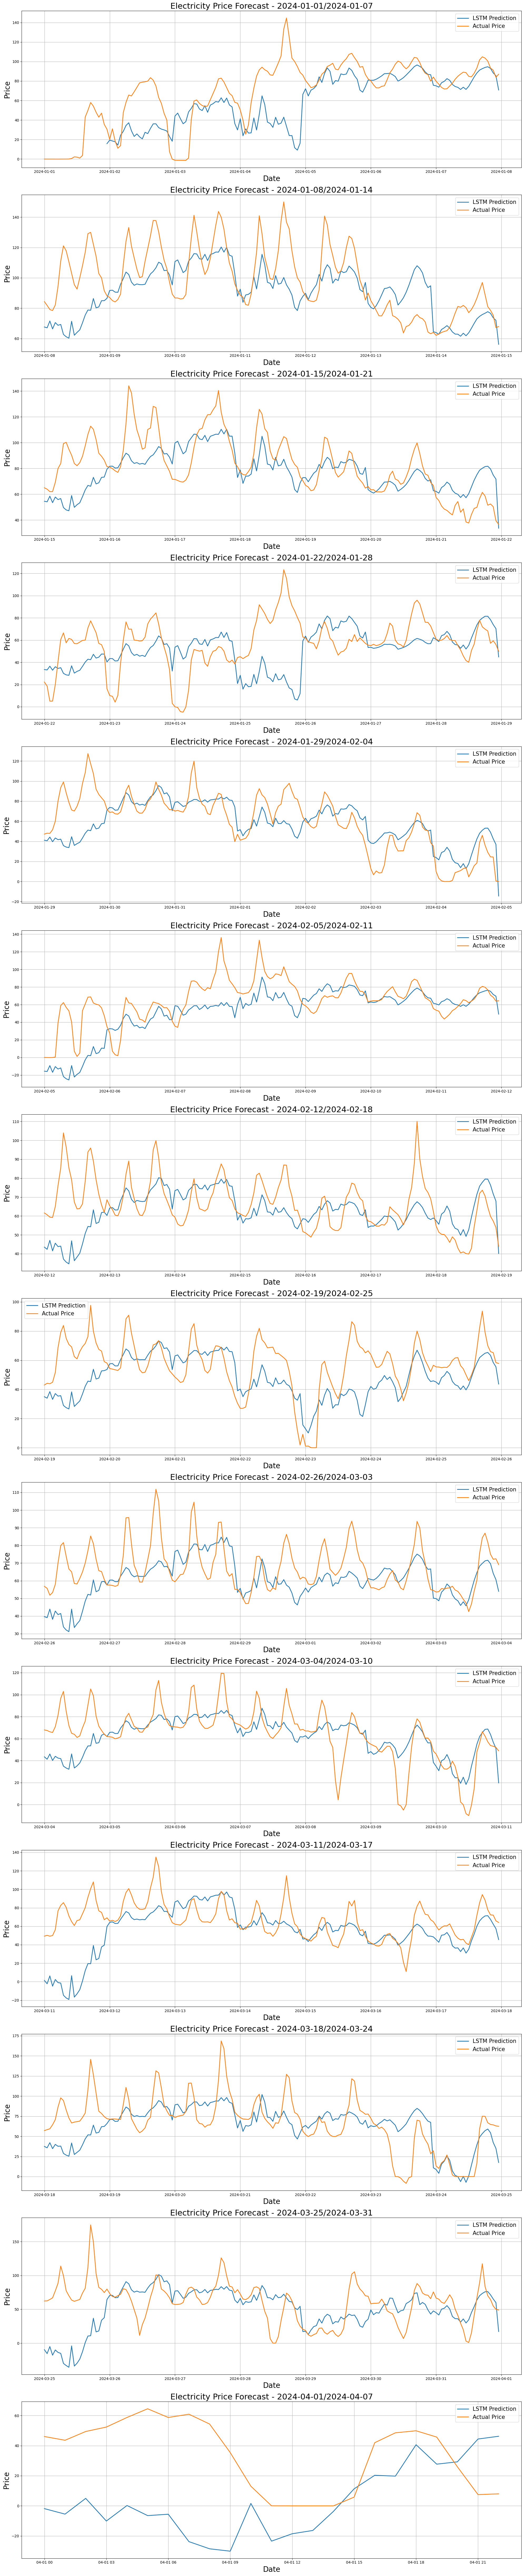

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'ds' is in datetime format
forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])
test_df['ds'] = pd.to_datetime(test_df['ds'])

# Create a new figure with multiple subplots, one for each biweekly period
# Group the data by biweekly periods
forecast_df['biweek'] = forecast_df['ds'].dt.to_period('2W')
test_df['biweek'] = test_df['ds'].dt.to_period('2W')

# Get the unique biweekly periods
unique_biweeks = forecast_df['biweek'].unique()

# Set up the figure and axes for plotting
fig, axes = plt.subplots(len(unique_biweeks), 1, figsize=(20, 7 * len(unique_biweeks)))

if len(unique_biweeks) == 1:
    axes = [axes]  # Ensure axes is iterable even if there's only one subplot

for i, biweek in enumerate(unique_biweeks):
    # Create the data subset for the current biweekly period
    biweek_str = str(biweek)
    forecast_biweek = forecast_df[forecast_df['biweek'] == biweek]
    test_biweek = test_df[test_df['biweek'] == biweek]

    # Plot predictions for the current biweekly period
    axes[i].plot(forecast_biweek['ds'], forecast_biweek['y_pred'], linewidth=2, label=f'{model_name} Prediction')

    # Plot actual test values for comparison in the current biweekly period
    axes[i].plot(test_biweek['ds'], test_biweek['y'], linewidth=2, label='Actual Price')

    # Formatting the plot for the current biweekly period
    axes[i].set_title(f'Electricity Price Forecast - {biweek_str}', fontsize=22)
    axes[i].set_ylabel('Price', fontsize=20)
    axes[i].set_xlabel('Date', fontsize=20)
    axes[i].legend(prop={'size': 15})
    axes[i].grid()

# Show the plot
plt.tight_layout()
plt.show()